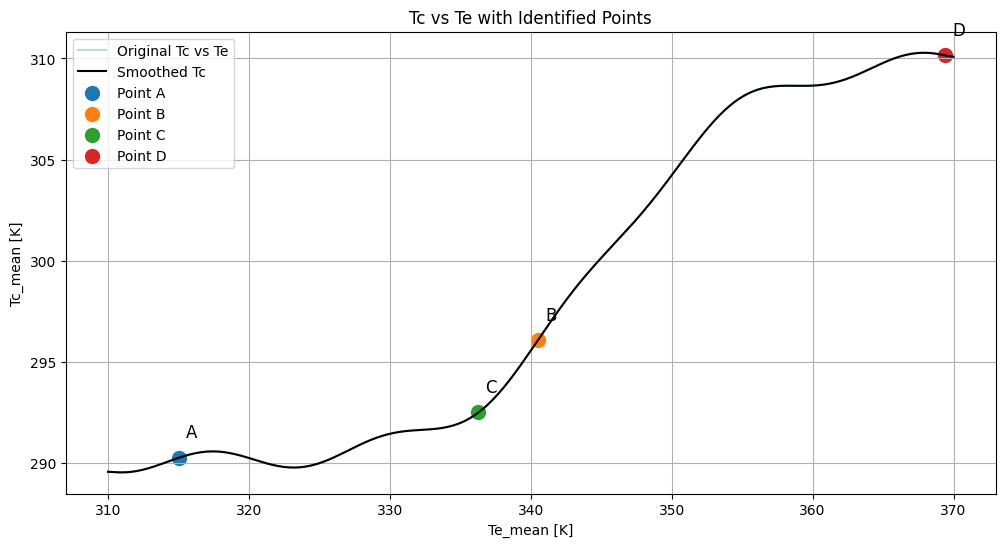

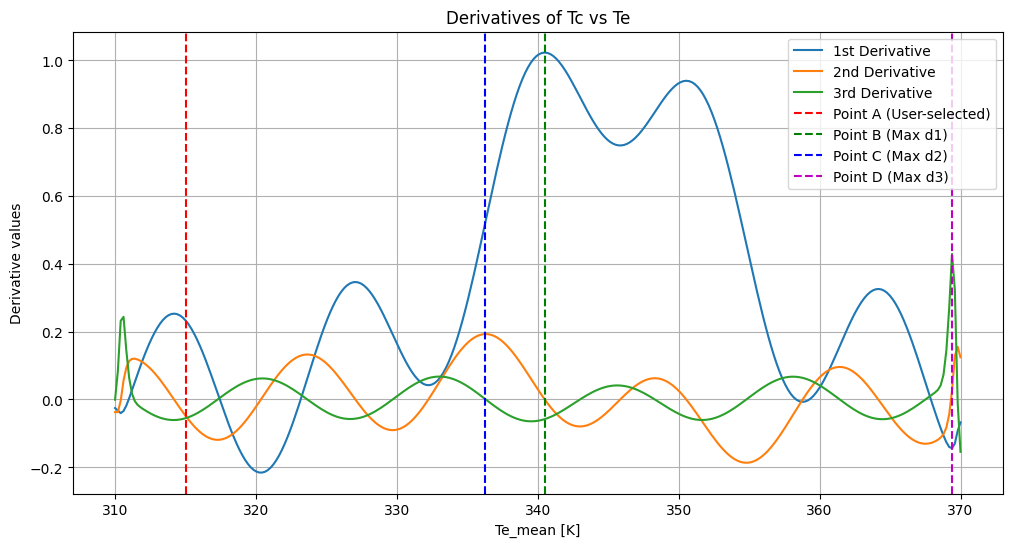

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- Step 1: Sample Data (Replace with your actual data) ----
# Example: Te_mean from 310K to 370K
Te = np.linspace(310, 370, 300)
# Simulate a sample Tc curve (similar shape to your image)
Tc = 300 + 10 * np.tanh(0.1*(Te - 345)) + 0.5 * np.sin(0.5 * Te)

# ---- Step 2: Smooth Data (Optional but recommended) ----
Tc_smooth = gaussian_filter1d(Tc, sigma=2)

# ---- Step 3: Compute Derivatives ----
d1 = np.gradient(Tc_smooth, Te)           # First derivative
d2 = np.gradient(d1, Te)                  # Second derivative
d3 = np.gradient(d2, Te)                  # Third derivative

# ---- Step 4: Identify Points ----
# Point A: manually chosen
point_A_Te = 315
point_A_idx = np.argmin(np.abs(Te - point_A_Te))

# Point B: Max slope
point_B_idx = np.argmax(d1)

# Point C: Max curvature
point_C_idx = np.argmax(d2)

# Point D: Max third derivative
point_D_idx = np.argmax(d3)

# ---- Plotting ----
plt.figure(figsize=(12, 6))
plt.plot(Te, Tc, label='Original Tc vs Te', alpha=0.3)
plt.plot(Te, Tc_smooth, label='Smoothed Tc', color='black')

# Mark points A, B, C, D
for idx, label in zip([point_A_idx, point_B_idx, point_C_idx, point_D_idx], ['A', 'B', 'C', 'D']):
    plt.scatter(Te[idx], Tc_smooth[idx], label=f'Point {label}', s=100)
    plt.text(Te[idx]+0.5, Tc_smooth[idx]+1, f'{label}', fontsize=12)

plt.xlabel('Te_mean [K]')
plt.ylabel('Tc_mean [K]')
plt.title('Tc vs Te with Identified Points')
plt.legend()
plt.grid(True)
plt.show()

# ---- Optional: Plot Derivatives ----
plt.figure(figsize=(12, 6))
plt.plot(Te, d1, label='1st Derivative')
plt.plot(Te, d2, label='2nd Derivative')
plt.plot(Te, d3, label='3rd Derivative')
plt.axvline(Te[point_A_idx], color='r', linestyle='--', label='Point A (User-selected)')
plt.axvline(Te[point_B_idx], color='g', linestyle='--', label='Point B (Max d1)')
plt.axvline(Te[point_C_idx], color='b', linestyle='--', label='Point C (Max d2)')
plt.axvline(Te[point_D_idx], color='m', linestyle='--', label='Point D (Max d3)')
plt.xlabel('Te_mean [K]')
plt.ylabel('Derivative values')
plt.title('Derivatives of Tc vs Te')
plt.legend()
plt.grid(True)
plt.show()


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore
csv_path = 'database.csv'
df = pd.read_csv(csv_path)

In [29]:
df.head()

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
0,11:32:06,04/04/2024,36.3,36.7,36.1,36.0,35.9,33.5,33.2,33.3,...,0.42,309.35,305.77,273.47,274.57,340.31,0.09,-2246.07,-2220.11,-25.96
1,11:32:08,04/04/2024,36.6,36.9,36.3,36.2,36.1,33.5,33.2,33.3,...,0.42,309.57,305.77,273.48,274.57,340.31,0.09,-2247.67,-2220.11,-27.55
2,11:32:09,04/04/2024,36.6,36.9,36.3,36.2,36.1,33.5,33.2,33.2,...,0.42,309.57,305.75,273.48,274.56,340.31,0.10,-2247.67,-2219.93,-27.74
3,11:32:10,04/04/2024,36.6,36.9,36.3,36.2,36.1,33.5,33.2,33.2,...,0.42,309.57,305.75,273.48,274.56,340.31,0.10,-2247.67,-2219.93,-27.74
4,11:32:12,04/04/2024,36.6,36.9,36.3,36.2,36.1,33.5,33.2,33.2,...,0.42,309.57,305.75,273.48,274.56,340.31,0.10,-2247.67,-2219.93,-27.74


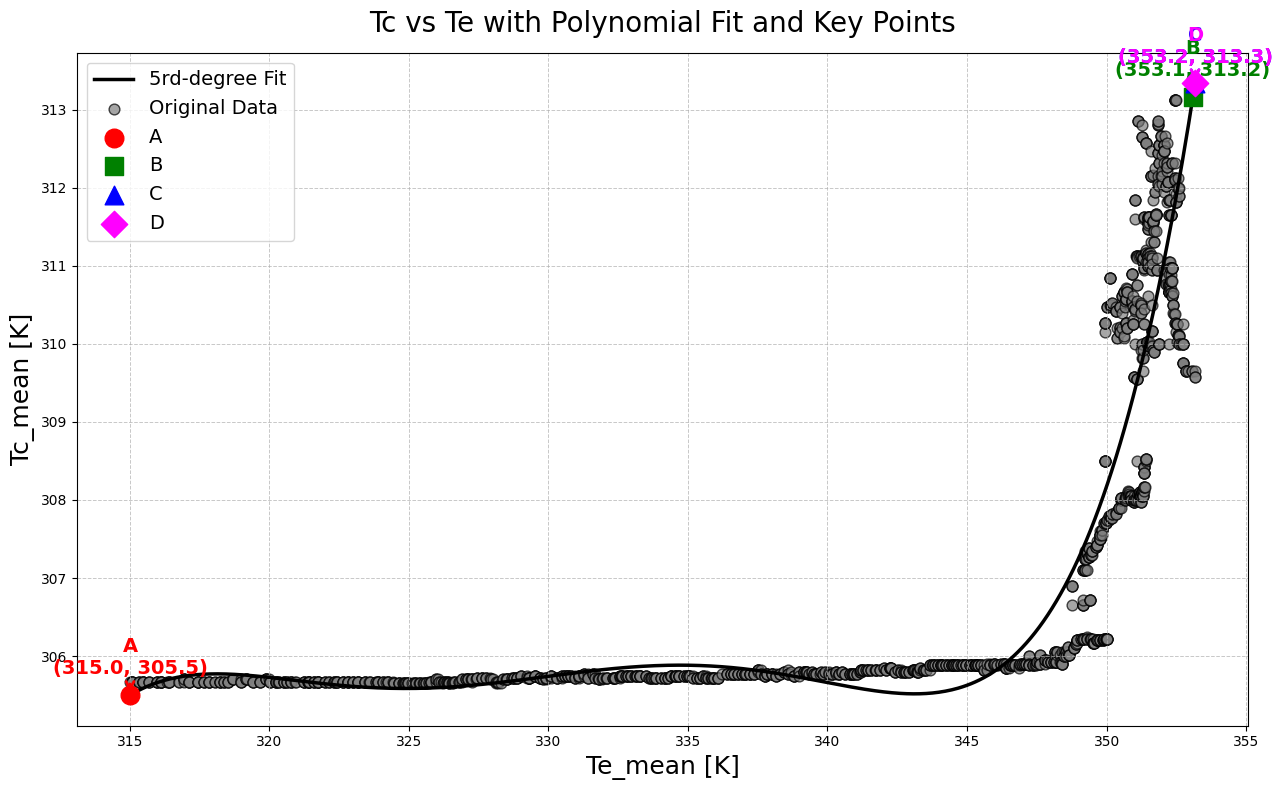

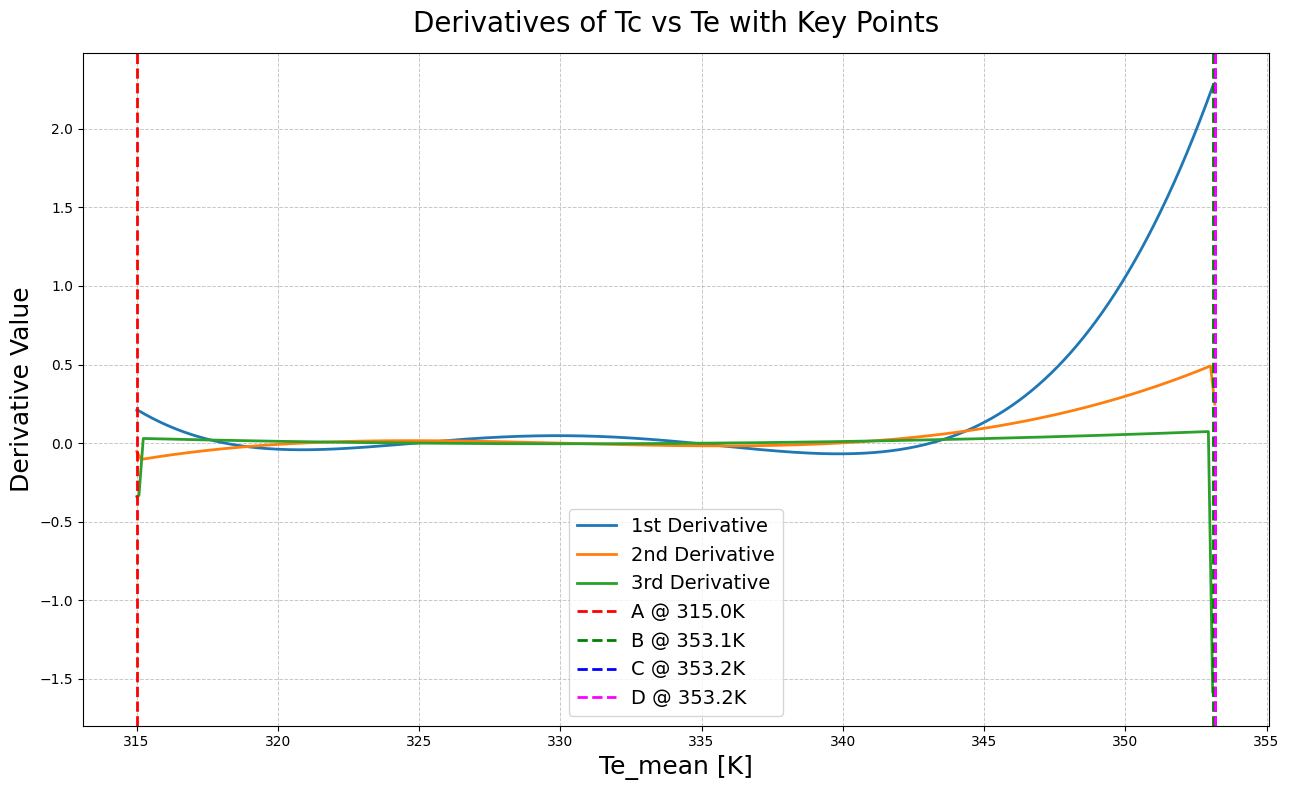

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

# --- Step 1: Load data ---
csv_path = 'database.csv'
df = pd.read_csv(csv_path)

# --- Step 2: Select condition and filter range ---
Q, FR, alpha, beta = 40, 60, 90, 0
point_A_Te = 315  # User-defined A

# Filter for condition
df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]

# Filter for Te range (optional, can be adjusted)
te_min, te_max = 315, 370
df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()

if df_filtered.empty:
    print("No data found for given condition and range.")
else:
    # --- Step 3: Remove outliers using Z-score (on Tc) ---
    df_filtered = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < 2.5]
    
    # --- Step 4: Polynomial fit (degree can be adjusted) ---
    df_filtered = df_filtered.sort_values('Te_mean[K]')
    Te = df_filtered['Te_mean[K]'].values
    Tc = df_filtered['Tc_mean[K]'].values
    poly_deg = 5
    coeffs = np.polyfit(Te, Tc, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Tc_fit = poly(Te_fine)

    # --- Step 5: Estimate derivatives using np.gradient ---
    d1 = np.gradient(Tc_fit, Te_fine)  # 1st derivative
    d2 = np.gradient(d1, Te_fine)      # 2nd derivative
    d3 = np.gradient(d2, Te_fine)      # 3rd derivative

    # --- Step 6: Identify A, B, C, D in sequence (with robust checks) ---
    point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    point_D_idx = len(Te_fine) - 1  # Last index (max Te)

    # B: max 1st derivative after A and before D
    B_range = slice(point_A_idx + 1, point_D_idx)
    if B_range.start < B_range.stop:
        point_B_idx = B_range.start + np.argmax(d1[B_range])
    else:
        point_B_idx = point_D_idx

    # C: max 2nd derivative after B and before D
    C_range = slice(point_B_idx + 1, point_D_idx)
    if C_range.start < C_range.stop:
        point_C_idx = C_range.start + np.argmax(d2[C_range])
    else:
        point_C_idx = point_D_idx

    # --- Step 7: Publication-quality plot: Fit + points + original data ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, Tc_fit, '-', color='black', linewidth=2.5, label=f'{poly_deg}rd-degree Fit')
    plt.scatter(Te, Tc, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    
    # Highlight points A–D
    points = {'A': point_A_idx, 'B': point_B_idx, 'C': point_C_idx, 'D': point_D_idx}
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], Tc_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {Tc_fit[idx]:.1f})',
                     (Te_fine[idx], Tc_fit[idx]),
                     textcoords="offset points", xytext=(0,15), ha='center', fontsize=14, color=colors[label], fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[label], lw=2))
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Tc_mean [K]', fontsize=18)
    plt.title('Tc vs Te with Polynomial Fit and Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # --- Step 8: Publication-quality plot: Derivatives ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, d1, label='1st Derivative', linewidth=2)
    plt.plot(Te_fine, d2, label='2nd Derivative', linewidth=2)
    plt.plot(Te_fine, d3, label='3rd Derivative', linewidth=2)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, label=f'{label} @ {Te_fine[idx]:.1f}K')
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Derivative Value', fontsize=18)
    plt.title('Derivatives of Tc vs Te with Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

In [31]:
print(df['Q[W]'].unique())

[ 40  60  80 100 120]


In [32]:
print(df['FR[%]'].unique())

[60]


In [33]:
print(df['alpha'].unique())

[90]


In [34]:
print(df['beta'].unique())

[0]


In [35]:
print(df['Te_mean[K]'].min(), df['Te_mean[K]'].max())

305.03 372.01


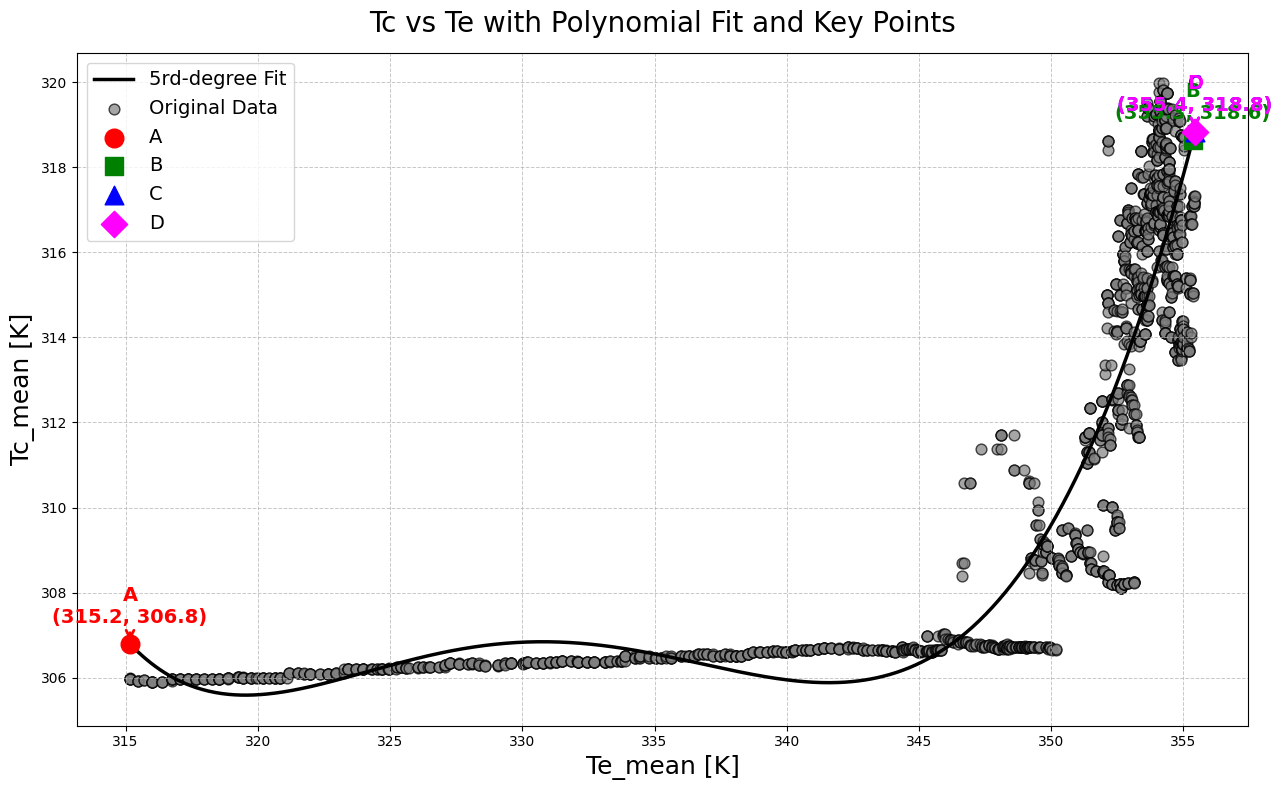

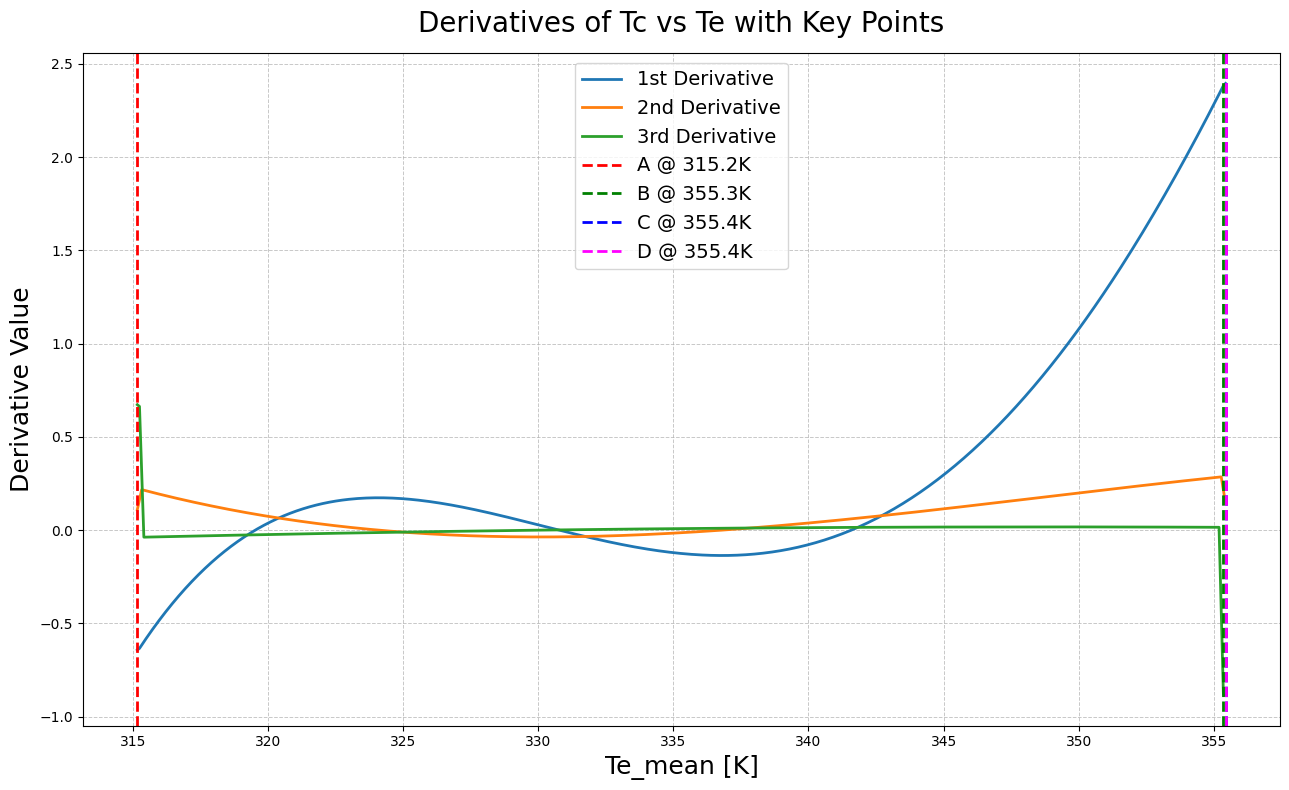

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

# --- Step 1: Load data ---
csv_path = 'database.csv'
df = pd.read_csv(csv_path)

# --- Step 2: Select condition and filter range ---
Q, FR, alpha, beta = 60, 60, 90, 0
point_A_Te = 315  # User-defined A

# Filter for condition
df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]

# Filter for Te range (optional, can be adjusted)
te_min, te_max = 315, 370
df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()

if df_filtered.empty:
    print("No data found for given condition and range.")
else:
    # --- Step 3: Remove outliers using Z-score (on Tc) ---
    df_filtered = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < 2.5]
    
    # --- Step 4: Polynomial fit (degree can be adjusted) ---
    df_filtered = df_filtered.sort_values('Te_mean[K]')
    Te = df_filtered['Te_mean[K]'].values
    Tc = df_filtered['Tc_mean[K]'].values
    poly_deg = 5
    coeffs = np.polyfit(Te, Tc, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Tc_fit = poly(Te_fine)

    # --- Step 5: Estimate derivatives using np.gradient ---
    d1 = np.gradient(Tc_fit, Te_fine)  # 1st derivative
    d2 = np.gradient(d1, Te_fine)      # 2nd derivative
    d3 = np.gradient(d2, Te_fine)      # 3rd derivative

    # --- Step 6: Identify A, B, C, D in sequence (with robust checks) ---
    point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    point_D_idx = len(Te_fine) - 1  # Last index (max Te)

    # B: max 1st derivative after A and before D
    B_range = slice(point_A_idx + 1, point_D_idx)
    if B_range.start < B_range.stop:
        point_B_idx = B_range.start + np.argmax(d1[B_range])
    else:
        point_B_idx = point_D_idx

    # C: max 2nd derivative after B and before D
    C_range = slice(point_B_idx + 1, point_D_idx)
    if C_range.start < C_range.stop:
        point_C_idx = C_range.start + np.argmax(d2[C_range])
    else:
        point_C_idx = point_D_idx

    # --- Step 7: Publication-quality plot: Fit + points + original data ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, Tc_fit, '-', color='black', linewidth=2.5, label=f'{poly_deg}rd-degree Fit')
    plt.scatter(Te, Tc, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    
    # Highlight points A–D
    points = {'A': point_A_idx, 'B': point_B_idx, 'C': point_C_idx, 'D': point_D_idx}
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], Tc_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {Tc_fit[idx]:.1f})',
                     (Te_fine[idx], Tc_fit[idx]),
                     textcoords="offset points", xytext=(0,15), ha='center', fontsize=14, color=colors[label], fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[label], lw=2))
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Tc_mean [K]', fontsize=18)
    plt.title('Tc vs Te with Polynomial Fit and Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # --- Step 8: Publication-quality plot: Derivatives ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, d1, label='1st Derivative', linewidth=2)
    plt.plot(Te_fine, d2, label='2nd Derivative', linewidth=2)
    plt.plot(Te_fine, d3, label='3rd Derivative', linewidth=2)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, label=f'{label} @ {Te_fine[idx]:.1f}K')
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Derivative Value', fontsize=18)
    plt.title('Derivatives of Tc vs Te with Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

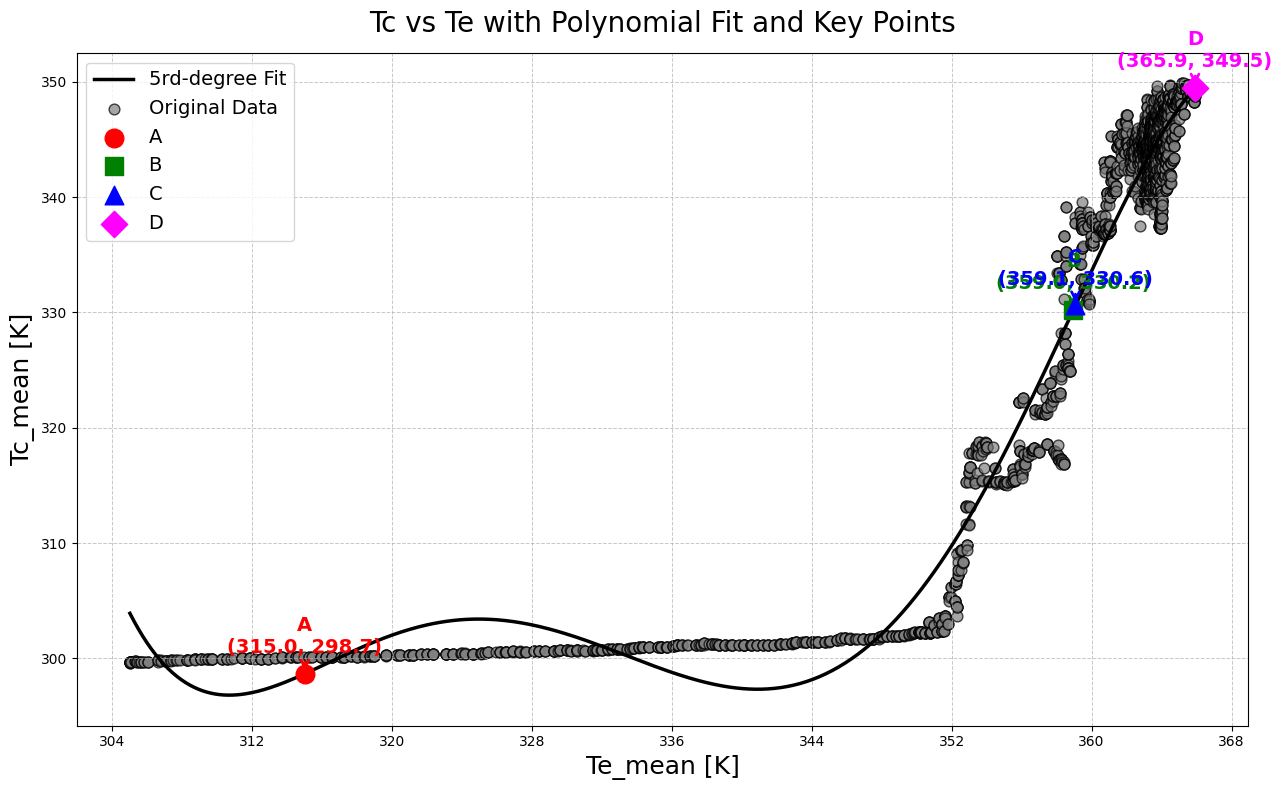

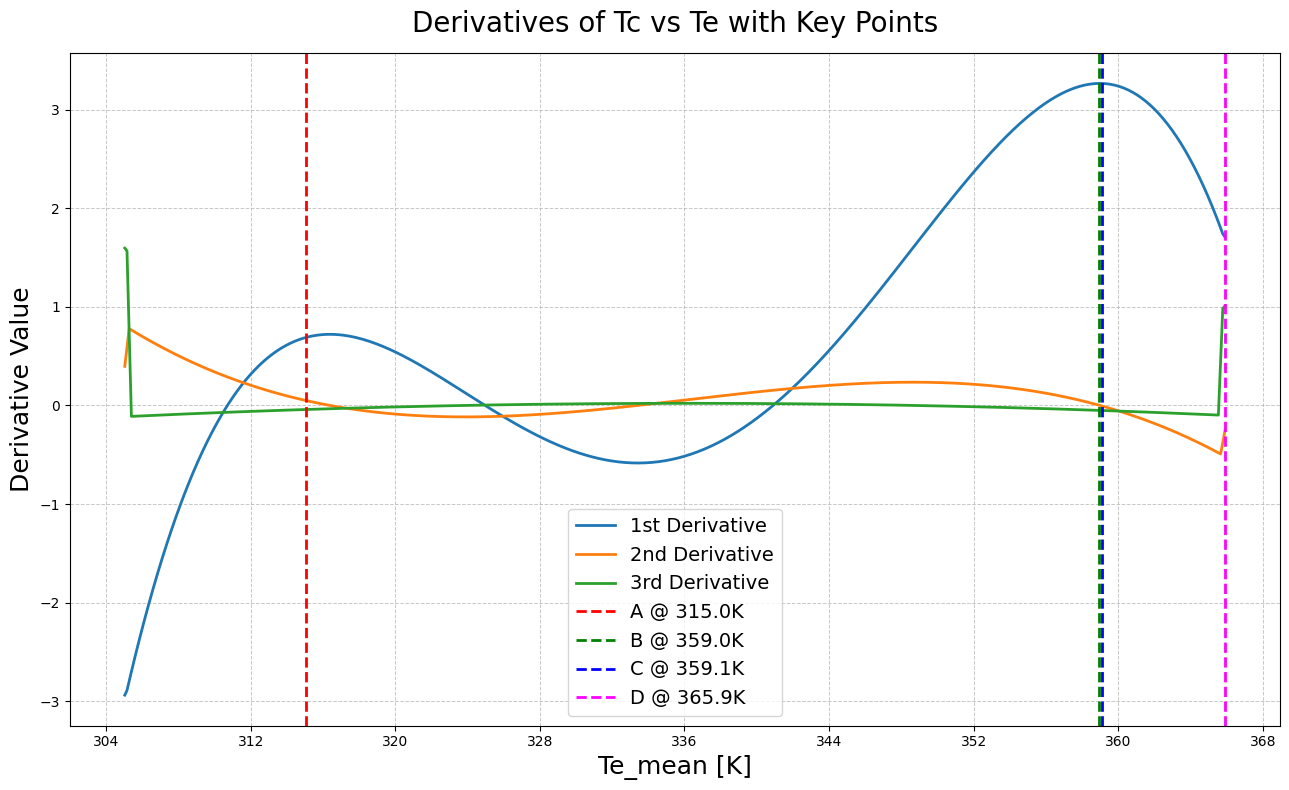

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

# --- Step 1: Load data ---
csv_path = 'database.csv'
df = pd.read_csv(csv_path)

# --- Step 2: Select condition and filter range ---
Q, FR, alpha, beta = 80, 60, 90, 0
point_A_Te = 315  # User-defined A

# Filter for condition
df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]

# Filter for Te range (optional, can be adjusted)
te_min, te_max = 305, 370
df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()

if df_filtered.empty:
    print("No data found for given condition and range.")
else:
    # --- Step 3: Remove outliers using Z-score (on Tc) ---
    df_filtered = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < 2.5]
    
    # --- Step 4: Polynomial fit (degree can be adjusted) ---
    df_filtered = df_filtered.sort_values('Te_mean[K]')
    Te = df_filtered['Te_mean[K]'].values
    Tc = df_filtered['Tc_mean[K]'].values
    poly_deg = 5
    coeffs = np.polyfit(Te, Tc, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Tc_fit = poly(Te_fine)

    # --- Step 5: Estimate derivatives using np.gradient ---
    d1 = np.gradient(Tc_fit, Te_fine)  # 1st derivative
    d2 = np.gradient(d1, Te_fine)      # 2nd derivative
    d3 = np.gradient(d2, Te_fine)      # 3rd derivative

    # --- Step 6: Identify A, B, C, D in sequence ---
    point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    point_D_idx = len(Te_fine) - 1  # Last index (max Te)
    # B: max 1st derivative after A and before D
    B_range = slice(point_A_idx + 1, point_D_idx)
    point_B_idx = B_range.start + np.argmax(d1[B_range])
    # C: max 2nd derivative after B and before D
    C_range = slice(point_B_idx + 1, point_D_idx)
    point_C_idx = C_range.start + np.argmax(d2[C_range])

    # --- Step 7: Publication-quality plot: Fit + points + original data ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, Tc_fit, '-', color='black', linewidth=2.5, label=f'{poly_deg}rd-degree Fit')
    plt.scatter(Te, Tc, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    
    # Highlight points A–D
    points = {'A': point_A_idx, 'B': point_B_idx, 'C': point_C_idx, 'D': point_D_idx}
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], Tc_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {Tc_fit[idx]:.1f})',
                     (Te_fine[idx], Tc_fit[idx]),
                     textcoords="offset points", xytext=(0,15), ha='center', fontsize=14, color=colors[label], fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[label], lw=2))
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Tc_mean [K]', fontsize=18)
    plt.title('Tc vs Te with Polynomial Fit and Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # --- Step 8: Publication-quality plot: Derivatives ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, d1, label='1st Derivative', linewidth=2)
    plt.plot(Te_fine, d2, label='2nd Derivative', linewidth=2)
    plt.plot(Te_fine, d3, label='3rd Derivative', linewidth=2)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, label=f'{label} @ {Te_fine[idx]:.1f}K')
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Derivative Value', fontsize=18)
    plt.title('Derivatives of Tc vs Te with Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

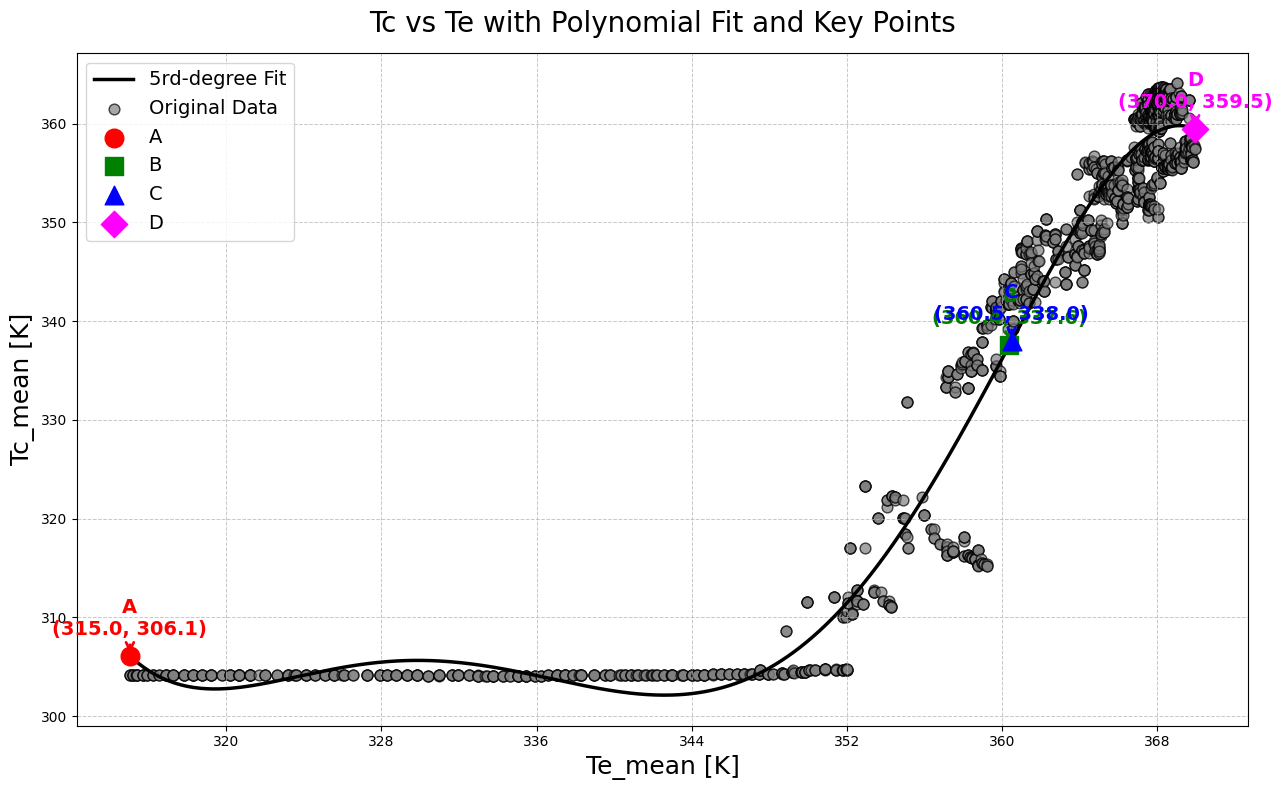

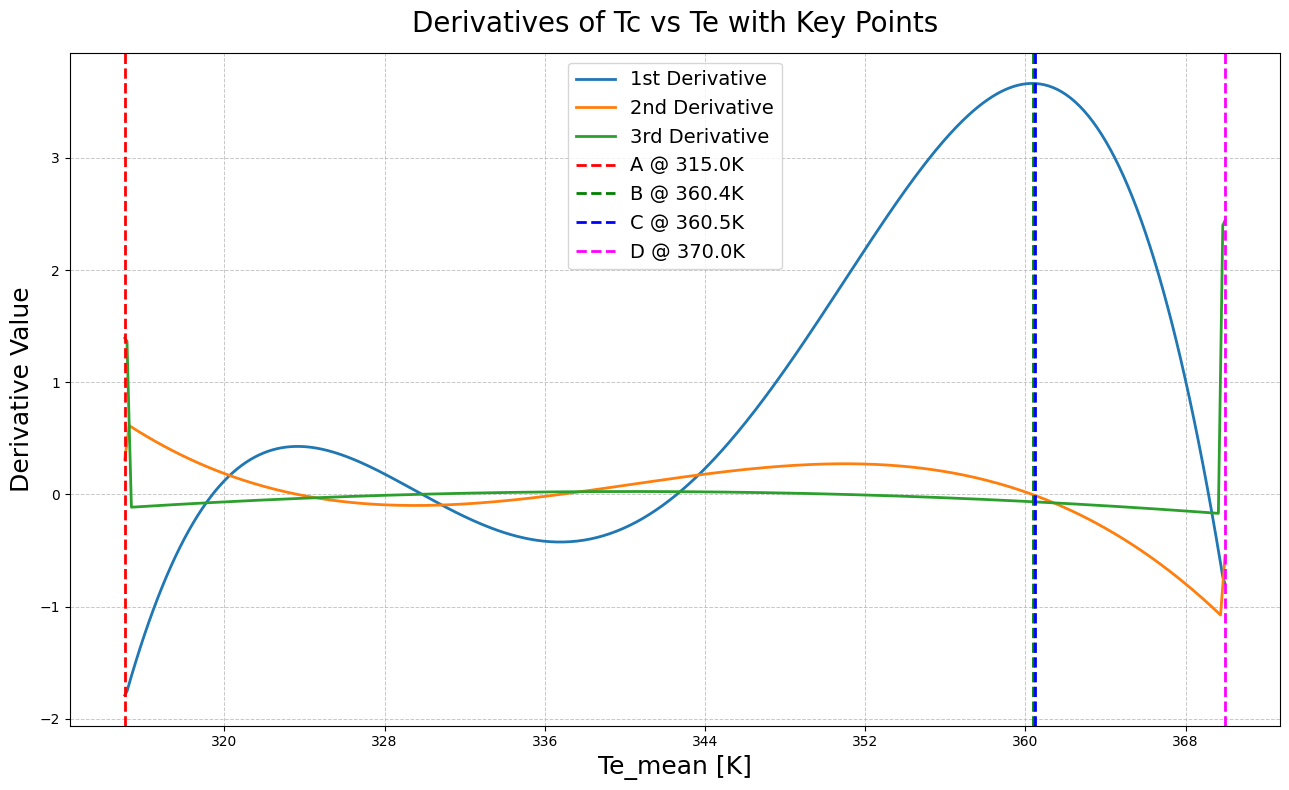

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

# --- Step 1: Load data ---
csv_path = 'database.csv'
df = pd.read_csv(csv_path)

# --- Step 2: Select condition and filter range ---
Q, FR, alpha, beta = 100, 60, 90, 0
point_A_Te = 315  # User-defined A

# Filter for condition
df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]

# Filter for Te range (optional, can be adjusted)
te_min, te_max = 315, 370
df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()

if df_filtered.empty:
    print("No data found for given condition and range.")
else:
    # --- Step 3: Remove outliers using Z-score (on Tc) ---
    df_filtered = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < 2.5]
    
    # --- Step 4: Polynomial fit (degree can be adjusted) ---
    df_filtered = df_filtered.sort_values('Te_mean[K]')
    Te = df_filtered['Te_mean[K]'].values
    Tc = df_filtered['Tc_mean[K]'].values
    poly_deg = 5
    coeffs = np.polyfit(Te, Tc, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Tc_fit = poly(Te_fine)

    # --- Step 5: Estimate derivatives using np.gradient ---
    d1 = np.gradient(Tc_fit, Te_fine)  # 1st derivative
    d2 = np.gradient(d1, Te_fine)      # 2nd derivative
    d3 = np.gradient(d2, Te_fine)      # 3rd derivative

    # --- Step 6: Identify A, B, C, D in sequence ---
    point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    point_D_idx = len(Te_fine) - 1  # Last index (max Te)
    # B: max 1st derivative after A and before D
    B_range = slice(point_A_idx + 1, point_D_idx)
    point_B_idx = B_range.start + np.argmax(d1[B_range])
    # C: max 2nd derivative after B and before D
    C_range = slice(point_B_idx + 1, point_D_idx)
    #point_C_idx = C_range.start + np.argmax(d2[C_range])
    point_C_idx = point_B_idx
    # --- Step 7: Publication-quality plot: Fit + points + original data ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, Tc_fit, '-', color='black', linewidth=2.5, label=f'{poly_deg}rd-degree Fit')
    plt.scatter(Te, Tc, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    
    # Highlight points A–D
    points = {'A': point_A_idx, 'B': point_B_idx, 'C': point_C_idx, 'D': point_D_idx}
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], Tc_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {Tc_fit[idx]:.1f})',
                     (Te_fine[idx], Tc_fit[idx]),
                     textcoords="offset points", xytext=(0,15), ha='center', fontsize=14, color=colors[label], fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[label], lw=2))
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Tc_mean [K]', fontsize=18)
    plt.title('Tc vs Te with Polynomial Fit and Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # --- Step 8: Publication-quality plot: Derivatives ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, d1, label='1st Derivative', linewidth=2)
    plt.plot(Te_fine, d2, label='2nd Derivative', linewidth=2)
    plt.plot(Te_fine, d3, label='3rd Derivative', linewidth=2)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, label=f'{label} @ {Te_fine[idx]:.1f}K')
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Derivative Value', fontsize=18)
    plt.title('Derivatives of Tc vs Te with Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

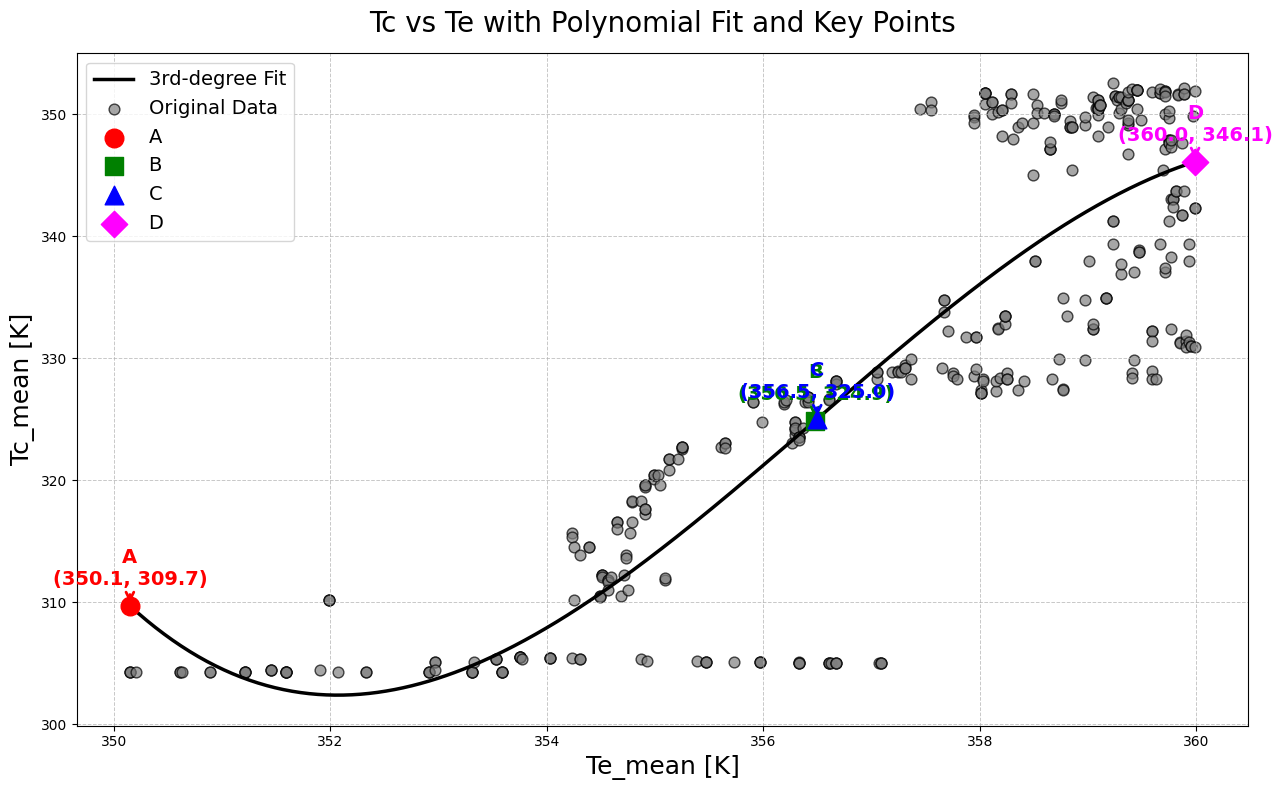

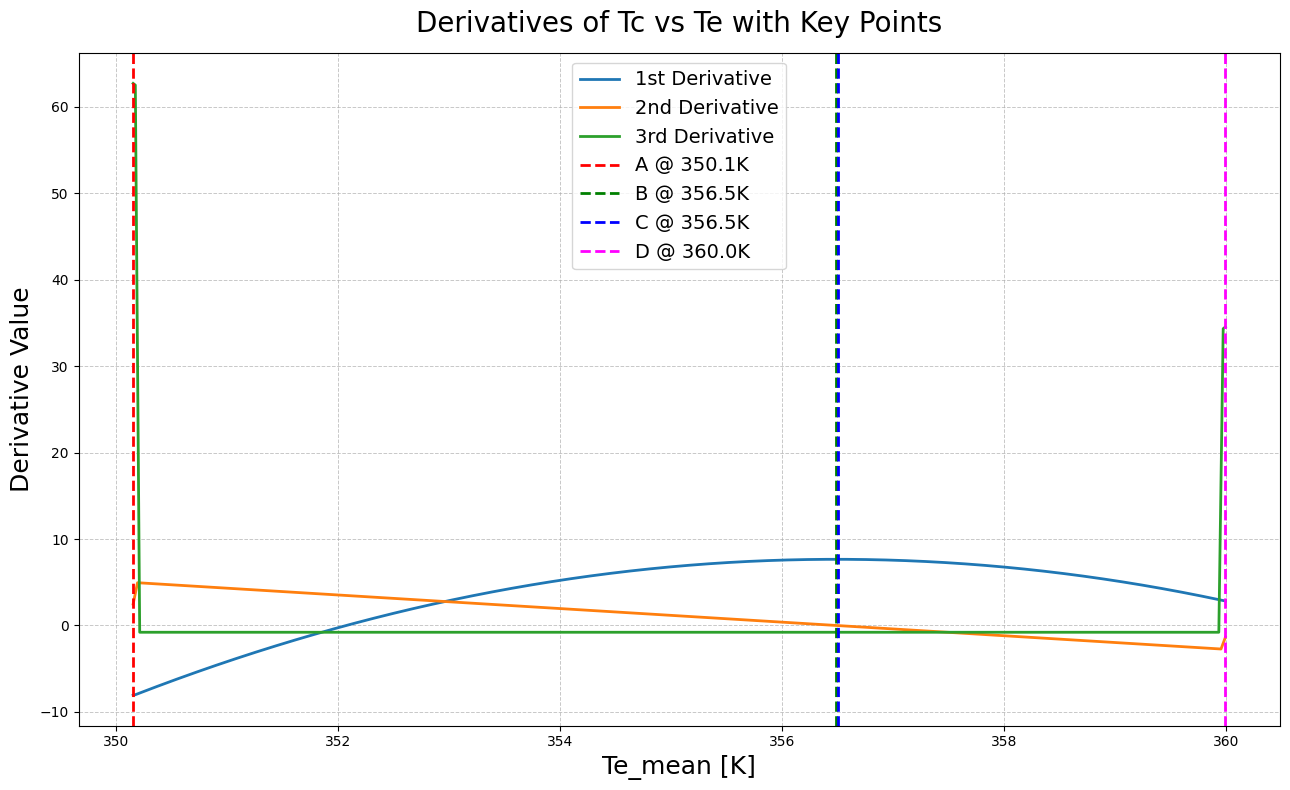

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

# --- Step 1: Load data ---
csv_path = 'database.csv'
df = pd.read_csv(csv_path)

# --- Step 2: Select condition and filter range ---
Q, FR, alpha, beta = 120, 60, 90, 0
point_A_Te = 315  # User-defined A

# Filter for condition
df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]

# Filter for Te range (optional, can be adjusted)
te_min, te_max = 350, 360
df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()

if df_filtered.empty:
    print("No data found for given condition and range.")
else:
    # --- Step 3: Remove outliers using Z-score (on Tc) ---
    df_filtered = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < 2.5]
    
    # --- Step 4: Polynomial fit (degree can be adjusted) ---
    df_filtered = df_filtered.sort_values('Te_mean[K]')
    Te = df_filtered['Te_mean[K]'].values
    Tc = df_filtered['Tc_mean[K]'].values
    poly_deg = 3
    coeffs = np.polyfit(Te, Tc, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Tc_fit = poly(Te_fine)

    # --- Step 5: Estimate derivatives using np.gradient ---
    d1 = np.gradient(Tc_fit, Te_fine)  # 1st derivative
    d2 = np.gradient(d1, Te_fine)      # 2nd derivative
    d3 = np.gradient(d2, Te_fine)      # 3rd derivative

    # --- Step 6: Identify A, B, C, D in sequence ---
    point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    point_D_idx = len(Te_fine) - 1  # Last index (max Te)
    # B: max 1st derivative after A and before D
    B_range = slice(point_A_idx + 1, point_D_idx)
    point_B_idx = B_range.start + np.argmax(d1[B_range])
    # C: max 2nd derivative after B and before D
    C_range = slice(point_B_idx + 1, point_D_idx)
    point_C_idx = C_range.start + np.argmax(d2[C_range]) if C_range.start < C_range.stop else point_D_idx

    # --- Step 7: Publication-quality plot: Fit + points + original data ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, Tc_fit, '-', color='black', linewidth=2.5, label=f'{poly_deg}rd-degree Fit')
    plt.scatter(Te, Tc, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    
    # Highlight points A–D
    points = {'A': point_A_idx, 'B': point_B_idx, 'C': point_C_idx, 'D': point_D_idx}
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], Tc_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {Tc_fit[idx]:.1f})',
                     (Te_fine[idx], Tc_fit[idx]),
                     textcoords="offset points", xytext=(0,15), ha='center', fontsize=14, color=colors[label], fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[label], lw=2))
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Tc_mean [K]', fontsize=18)
    plt.title('Tc vs Te with Polynomial Fit and Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # --- Step 8: Publication-quality plot: Derivatives ---
    plt.figure(figsize=(13, 8))
    plt.plot(Te_fine, d1, label='1st Derivative', linewidth=2)
    plt.plot(Te_fine, d2, label='2nd Derivative', linewidth=2)
    plt.plot(Te_fine, d3, label='3rd Derivative', linewidth=2)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, label=f'{label} @ {Te_fine[idx]:.1f}K')
    plt.xlabel('Te_mean [K]', fontsize=18)
    plt.ylabel('Derivative Value', fontsize=18)
    plt.title('Derivatives of Tc vs Te with Key Points', fontsize=20, pad=15)
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()